In [5]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [6]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [7]:
from model.metrics import MSE, MAE, evaluate_linear_regression
from model.gradients import MSE_grad
from model.utils import *
import matplotlib.pyplot as plt

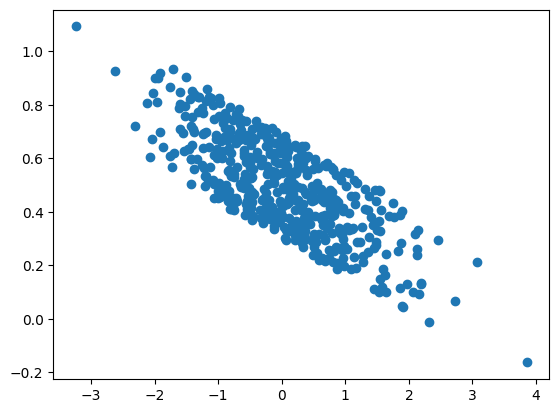

In [8]:
# Sample Code for generating datasets
seed=42
np.random.seed(seed)
size = 500
dim = 1
noise_bound = 0.2
X,y,W = generate_linear_dataset(size,dim,noise_bound=noise_bound,is_reg=True)
plt.scatter(X[:,1],y)

In [9]:
# Loading data
loaded_data = np.load(f'data/linear_data/linear_data_A.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

# Show the size of data
print(f"X size : {X.shape}, y size : {y.shape}")

# Make sure size and dim correct.
size = X.shape[0]
dim = X.shape[1]-1

X size : (1600, 2), y size : (1600,)


50. Training loss: 0.08822499761459246, Val loss:0.08344253861678516
100. Training loss: 0.024461533163063473, Val loss:0.022730598385935285
150. Training loss: 0.015054341888577384, Val loss:0.013961184271627123
200. Training loss: 0.013664791563666538, Val loss:0.012739408114859366
250. Training loss: 0.013459321509937406, Val loss:0.012586753610002822
300. Training loss: 0.013428910982968287, Val loss:0.012574716912916001
350. Training loss: 0.013424406462249211, Val loss:0.01257690199190865
400. Training loss: 0.013423738769333433, Val loss:0.012578717009069202
450. Training loss: 0.013423639738964216, Val loss:0.012579546976647175
500. Training loss: 0.013423625043327498, Val loss:0.01257988125786218


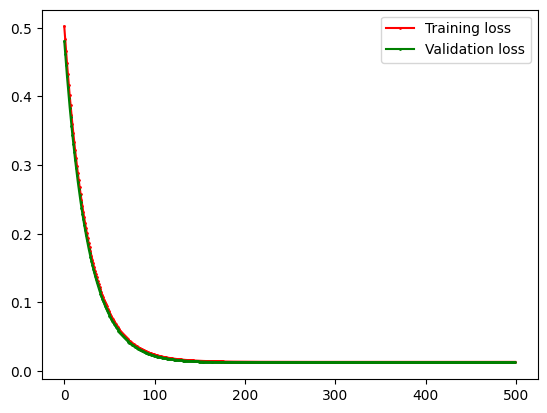

In [ ]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function and gradient.
loss_fn = MSE
grad_fn = MSE_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,True,loss_fn,grad_fn)
model.fit(X_train,y_train,lr=0.01,n_iteration =500,val_ratio=0.2)

In [11]:
# Get the Prediction
y_val_pred = model.predict(X_val)

In [ ]:
# Evaluation
# Please complete the evaluate_linear_regression in the model/metrics.py by the sklearn package.
evaluate_linear_regression(y_true=y_val,y_pred=y_val_pred,title='Linear Regression Evaluation')

=== Linear Regression Evaluation ===
MSE       : 0.0134
MAE       : 0.1010
RMSE      : 0.1156
R-squared : 0.5690


{'MSE': 0.013355229539356039,
 'MAE': 0.10095149880498926,
 'RMSE': np.float64(0.11556482829717717),
 'R-squared': 0.5689997481843656}

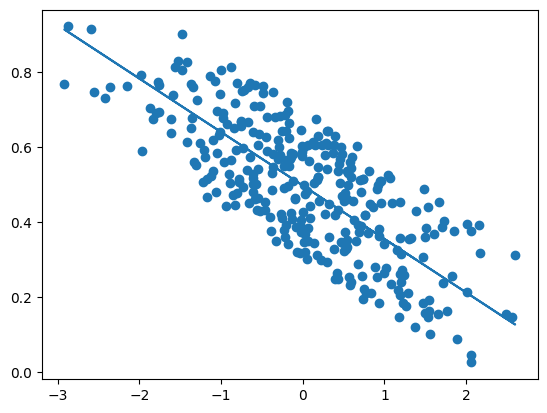

In [13]:
# Plot
plt.scatter(X_val[:,1],y_val)
plt.plot(X_val[:,1],y_val_pred)
plt.show()

# Full Experiment: All Datasets × All Learning Rates

For each dataset (A, B, C, D) and each learning rate (0.1, 0.01, 0.001), train a LinearModel with n_iteration=500 and evaluate on the validation set.

## Dataset A

50. Training loss: 0.013423623061455565, Val loss:0.012580010701461058
100. Training loss: 0.013423622480987135, Val loss:0.012580089713127157
150. Training loss: 0.013423622480987133, Val loss:0.012580089715050587
200. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
250. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
300. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
350. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
400. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
450. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
500. Training loss: 0.013423622480987133, Val loss:0.012580089715050636


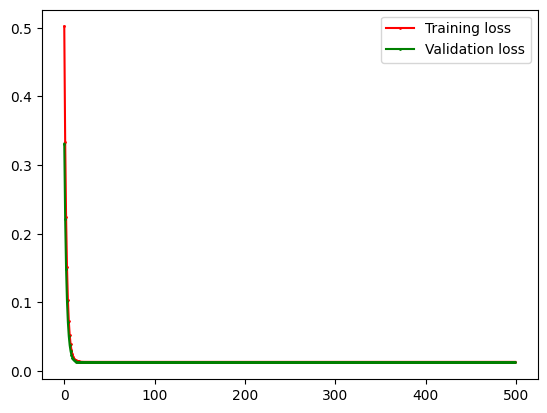

=== Linear Regression Evaluation - Dataset A, lr=0.1 ===
MSE       : 0.0134
MAE       : 0.1010
RMSE      : 0.1156
R-squared : 0.5690


{'MSE': 0.013356333749635324,
 'MAE': 0.10095600779556413,
 'RMSE': np.float64(0.11556960564800471),
 'R-squared': 0.5689641130867413}

In [14]:
# Dataset A, lr=0.1
loaded_data = np.load('data/linear_data/linear_data_A.npz')
X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']
size = X.shape[0]
dim = X.shape[1]-1

seed = 42
np.random.seed(seed)
X_train, y_train, X_val, y_val = get_train_val(X, y)

model = LinearModel(dim, True, MSE, MSE_grad)
model.fit(X_train, y_train, lr=0.1, n_iteration=500, val_ratio=0.2)

y_val_pred = model.predict(X_val)
evaluate_linear_regression(y_true=y_val, y_pred=y_val_pred, title='Linear Regression Evaluation - Dataset A, lr=0.1')

50. Training loss: 0.08822499761459246, Val loss:0.08344253861678516
100. Training loss: 0.024461533163063473, Val loss:0.022730598385935285
150. Training loss: 0.015054341888577384, Val loss:0.013961184271627123
200. Training loss: 0.013664791563666538, Val loss:0.012739408114859366
250. Training loss: 0.013459321509937406, Val loss:0.012586753610002822
300. Training loss: 0.013428910982968287, Val loss:0.012574716912916001
350. Training loss: 0.013424406462249211, Val loss:0.01257690199190865
400. Training loss: 0.013423738769333433, Val loss:0.012578717009069202
450. Training loss: 0.013423639738964216, Val loss:0.012579546976647175
500. Training loss: 0.013423625043327498, Val loss:0.01257988125786218


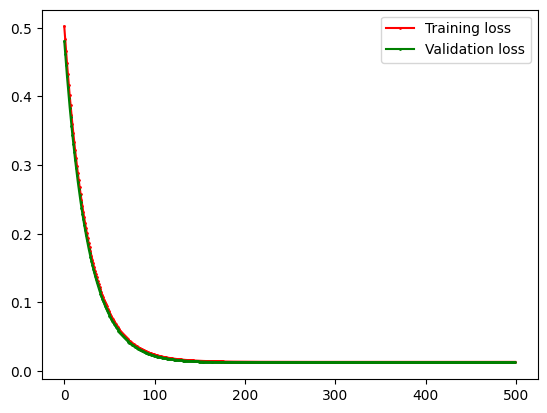

=== Linear Regression Evaluation - Dataset A, lr=0.01 ===
MSE       : 0.0134
MAE       : 0.1010
RMSE      : 0.1156
R-squared : 0.5690


{'MSE': 0.013355229539356039,
 'MAE': 0.10095149880498926,
 'RMSE': np.float64(0.11556482829717717),
 'R-squared': 0.5689997481843656}

In [15]:
# Dataset A, lr=0.01
loaded_data = np.load('data/linear_data/linear_data_A.npz')
X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']
size = X.shape[0]
dim = X.shape[1]-1

seed = 42
np.random.seed(seed)
X_train, y_train, X_val, y_val = get_train_val(X, y)

model = LinearModel(dim, True, MSE, MSE_grad)
model.fit(X_train, y_train, lr=0.01, n_iteration=500, val_ratio=0.2)

y_val_pred = model.predict(X_val)
evaluate_linear_regression(y_true=y_val, y_pred=y_val_pred, title='Linear Regression Evaluation - Dataset A, lr=0.01')

50. Training loss: 0.418984925274338, Val loss:0.41420880497204005
100. Training loss: 0.34884281364937003, Val loss:0.3445251797643867
150. Training loss: 0.2908358402579774, Val loss:0.28691334687110626
200. Training loss: 0.2428637953466062, Val loss:0.23928338706190336
250. Training loss: 0.20319008395293756, Val loss:0.19990713434668128
300. Training loss: 0.17037874765339453, Val loss:0.16735555250253287
350. Training loss: 0.14324239869173933, Val loss:0.1404469551481651
400. Training loss: 0.12079917484937551, Val loss:0.11820419110090803
450. Training loss: 0.10223715148116824, Val loss:0.09981924222927965
500. Training loss: 0.08688491828078371, Val loss:0.08462395006505144


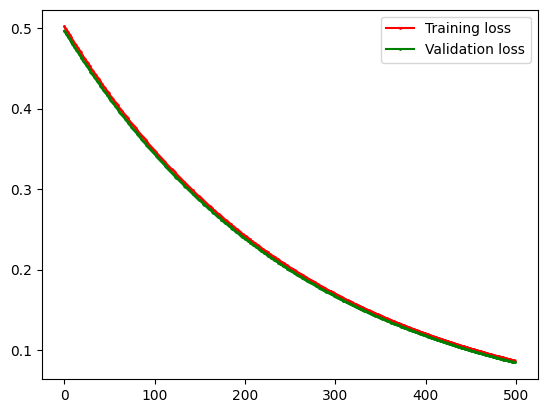

=== Linear Regression Evaluation - Dataset A, lr=0.001 ===
MSE       : 0.0832
MAE       : 0.2369
RMSE      : 0.2884
R-squared : -1.6836


{'MSE': 0.08315645283790848,
 'MAE': 0.23691757234746919,
 'RMSE': np.float64(0.28836860584659435),
 'R-squared': -1.6836268150701983}

In [16]:
# Dataset A, lr=0.001
loaded_data = np.load('data/linear_data/linear_data_A.npz')
X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']
size = X.shape[0]
dim = X.shape[1]-1

seed = 42
np.random.seed(seed)
X_train, y_train, X_val, y_val = get_train_val(X, y)

model = LinearModel(dim, True, MSE, MSE_grad)
model.fit(X_train, y_train, lr=0.001, n_iteration=500, val_ratio=0.2)

y_val_pred = model.predict(X_val)
evaluate_linear_regression(y_true=y_val, y_pred=y_val_pred, title='Linear Regression Evaluation - Dataset A, lr=0.001')

## Dataset B

50. Training loss: 0.21477796029761928, Val loss:0.20128111574984853
100. Training loss: 0.21477795969579408, Val loss:0.20128143543301202
150. Training loss: 0.2147779596957941, Val loss:0.20128143544080995
200. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
250. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
300. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
350. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
400. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
450. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
500. Training loss: 0.21477795969579408, Val loss:0.20128143544081017


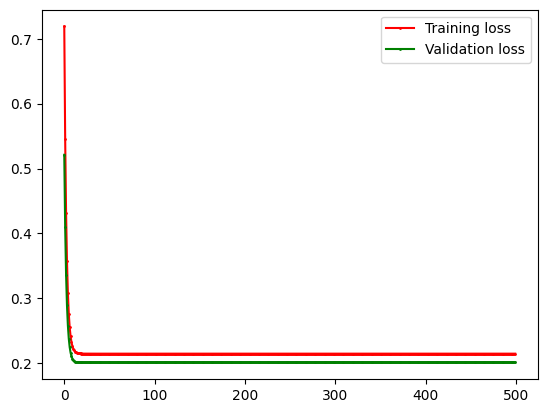

=== Linear Regression Evaluation - Dataset B, lr=0.1 ===
MSE       : 0.2137
MAE       : 0.4038
RMSE      : 0.4623
R-squared : 0.0448


{'MSE': 0.21370133999416518,
 'MAE': 0.4038240311822565,
 'RMSE': np.float64(0.46227842259201885),
 'R-squared': 0.04477536473581445}

In [17]:
# Dataset B, lr=0.1
loaded_data = np.load('data/linear_data/linear_data_B.npz')
X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']
size = X.shape[0]
dim = X.shape[1]-1

seed = 42
np.random.seed(seed)
X_train, y_train, X_val, y_val = get_train_val(X, y)

model = LinearModel(dim, True, MSE, MSE_grad)
model.fit(X_train, y_train, lr=0.1, n_iteration=500, val_ratio=0.2)

y_val_pred = model.predict(X_val)
evaluate_linear_regression(y_true=y_val, y_pred=y_val_pred, title='Linear Regression Evaluation - Dataset B, lr=0.1')

50. Training loss: 0.2920213425997664, Val loss:0.2702611408646165
100. Training loss: 0.22618379407532826, Val loss:0.2101879308116208
150. Training loss: 0.2164640141651331, Val loss:0.2021155812609517
200. Training loss: 0.21502743867502366, Val loss:0.20122361991141446
250. Training loss: 0.21481490508468085, Val loss:0.20120482979710497
300. Training loss: 0.21478343493349927, Val loss:0.20124452118342356
350. Training loss: 0.21477877162933798, Val loss:0.20126634873684507
400. Training loss: 0.21477808016505961, Val loss:0.20127557772119783
450. Training loss: 0.21477797757871428, Val loss:0.20127920153421996
500. Training loss: 0.2147779623514954, Val loss:0.20128058874123028


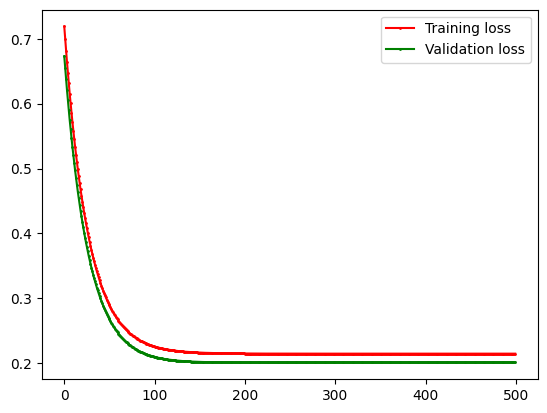

=== Linear Regression Evaluation - Dataset B, lr=0.01 ===
MSE       : 0.2137
MAE       : 0.4038
RMSE      : 0.4623
R-squared : 0.0448


{'MSE': 0.21369682365896048,
 'MAE': 0.40381943393609915,
 'RMSE': np.float64(0.4622735377013922),
 'R-squared': 0.04479555232401}

In [18]:
# Dataset B, lr=0.01
loaded_data = np.load('data/linear_data/linear_data_B.npz')
X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']
size = X.shape[0]
dim = X.shape[1]-1

seed = 42
np.random.seed(seed)
X_train, y_train, X_val, y_val = get_train_val(X, y)

model = LinearModel(dim, True, MSE, MSE_grad)
model.fit(X_train, y_train, lr=0.01, n_iteration=500, val_ratio=0.2)

y_val_pred = model.predict(X_val)
evaluate_linear_regression(y_true=y_val, y_pred=y_val_pred, title='Linear Regression Evaluation - Dataset B, lr=0.01')

50. Training loss: 0.6333011463329974, Val loss:0.605763731465133
100. Training loss: 0.560944176029853, Val loss:0.5347780170370382
150. Training loss: 0.5011005997675119, Val loss:0.47616215994096633
200. Training loss: 0.4516056474010014, Val loss:0.4277683253433776
250. Training loss: 0.41066917554133203, Val loss:0.3878209660417229
300. Training loss: 0.37681081233745717, Val loss:0.354852342304647
350. Training loss: 0.3488063343172151, Val loss:0.32764920718227697
400. Training loss: 0.32564332924740713, Val loss:0.3052087237083346
450. Training loss: 0.30648453628529515, Val loss:0.28670201534712025
500. Training loss: 0.2906375335120469, Val loss:0.27144402793270805


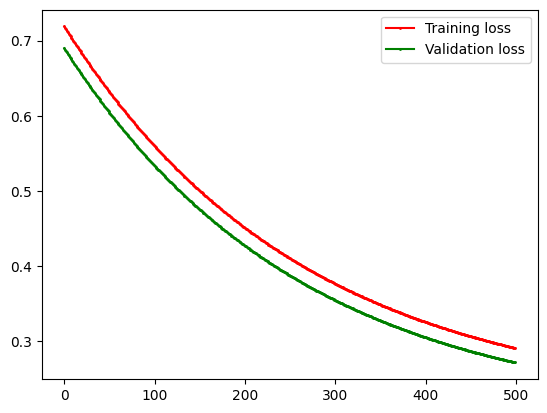

=== Linear Regression Evaluation - Dataset B, lr=0.001 ===
MSE       : 0.2687
MAE       : 0.4404
RMSE      : 0.5184
R-squared : -0.2011


{'MSE': 0.26870180820833145,
 'MAE': 0.4403913458737695,
 'RMSE': np.float64(0.5183645514580751),
 'R-squared': -0.20107148952663834}

In [19]:
# Dataset B, lr=0.001
loaded_data = np.load('data/linear_data/linear_data_B.npz')
X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']
size = X.shape[0]
dim = X.shape[1]-1

seed = 42
np.random.seed(seed)
X_train, y_train, X_val, y_val = get_train_val(X, y)

model = LinearModel(dim, True, MSE, MSE_grad)
model.fit(X_train, y_train, lr=0.001, n_iteration=500, val_ratio=0.2)

y_val_pred = model.predict(X_val)
evaluate_linear_regression(y_true=y_val, y_pred=y_val_pred, title='Linear Regression Evaluation - Dataset B, lr=0.001')

## Dataset C

50. Training loss: 0.0131818971313023, Val loss:0.013771656751385359
100. Training loss: 0.013181896123422132, Val loss:0.013771595669720494
150. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
200. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
250. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
300. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
350. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
400. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
450. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
500. Training loss: 0.013181896123422132, Val loss:0.013771595669175307


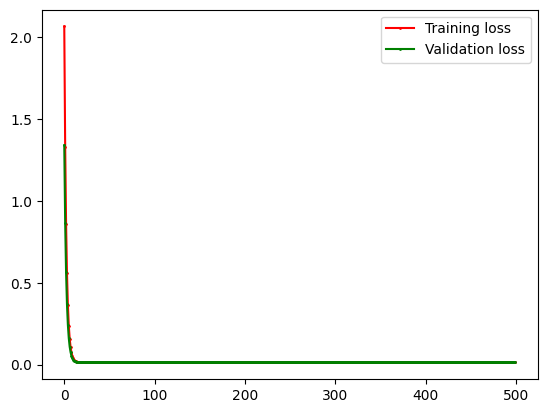

=== Linear Regression Evaluation - Dataset C, lr=0.1 ===
MSE       : 0.0132
MAE       : 0.0987
RMSE      : 0.1148
R-squared : 0.9954


{'MSE': 0.013182793631671172,
 'MAE': 0.09868229952957776,
 'RMSE': np.float64(0.11481634740606919),
 'R-squared': 0.9953516857442621}

In [20]:
# Dataset C, lr=0.1
loaded_data = np.load('data/linear_data/linear_data_C.npz')
X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']
size = X.shape[0]
dim = X.shape[1]-1

seed = 42
np.random.seed(seed)
X_train, y_train, X_val, y_val = get_train_val(X, y)

model = LinearModel(dim, True, MSE, MSE_grad)
model.fit(X_train, y_train, lr=0.1, n_iteration=500, val_ratio=0.2)

y_val_pred = model.predict(X_val)
evaluate_linear_regression(y_true=y_val, y_pred=y_val_pred, title='Linear Regression Evaluation - Dataset C, lr=0.1')

50. Training loss: 0.3016776572102272, Val loss:0.2940364008397445
100. Training loss: 0.052301281914569585, Val loss:0.052286225702638675
150. Training loss: 0.018505850726527058, Val loss:0.019175412162323584
200. Training loss: 0.013908983721033275, Val loss:0.014564896297918123
250. Training loss: 0.013281521987973383, Val loss:0.013899712449279154
300. Training loss: 0.01319558969139006, Val loss:0.013796096535113092
350. Training loss: 0.013183783898695744, Val loss:0.013777427806772765
400. Training loss: 0.013182157103470477, Val loss:0.013773277022245267
450. Training loss: 0.013181932299897786, Val loss:0.013772140690770074
500. Training loss: 0.013181901150900593, Val loss:0.013771782558303799


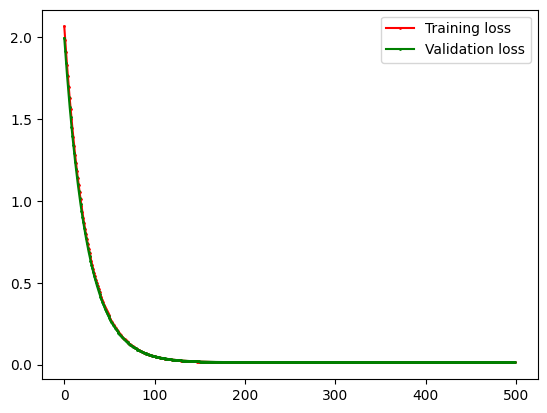

=== Linear Regression Evaluation - Dataset C, lr=0.01 ===
MSE       : 0.0132
MAE       : 0.0987
RMSE      : 0.1148
R-squared : 0.9954


{'MSE': 0.01318285194198864,
 'MAE': 0.09868109058967203,
 'RMSE': np.float64(0.11481660133442655),
 'R-squared': 0.9953516651837735}

In [21]:
# Dataset C, lr=0.01
loaded_data = np.load('data/linear_data/linear_data_C.npz')
X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']
size = X.shape[0]
dim = X.shape[1]-1

seed = 42
np.random.seed(seed)
X_train, y_train, X_val, y_val = get_train_val(X, y)

model = LinearModel(dim, True, MSE, MSE_grad)
model.fit(X_train, y_train, lr=0.01, n_iteration=500, val_ratio=0.2)

y_val_pred = model.predict(X_val)
evaluate_linear_regression(y_true=y_val, y_pred=y_val_pred, title='Linear Regression Evaluation - Dataset C, lr=0.01')

50. Training loss: 1.7022307356186879, Val loss:1.704399561902757
100. Training loss: 1.398099093422373, Val loss:1.4007211470145513
150. Training loss: 1.1487734111234604, Val loss:1.1516658664027397
200. Training loss: 0.9443693636081101, Val loss:0.9473976449419805
250. Training loss: 0.7767867515803092, Val loss:0.7798533335010577
300. Training loss: 0.6393871949572303, Val loss:0.642422853410673
350. Training loss: 0.5267301015086948, Val loss:0.5296870971374619
400. Training loss: 0.4343563650291918, Val loss:0.43720314708376423
450. Training loss: 0.3586111574044348, Val loss:0.3613282625111077
500. Training loss: 0.29649874274023047, Val loss:0.299075630842221


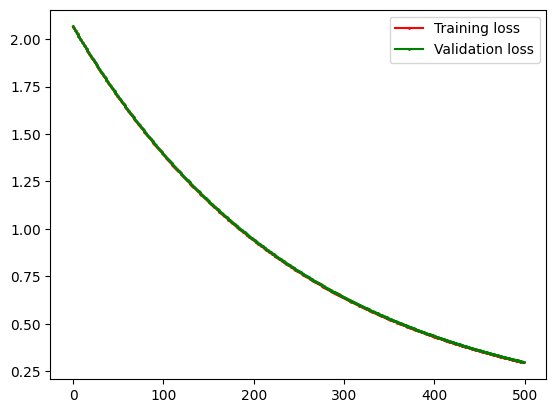

=== Linear Regression Evaluation - Dataset C, lr=0.001 ===
MSE       : 0.2852
MAE       : 0.4273
RMSE      : 0.5341
R-squared : 0.8994


{'MSE': 0.28522489191953326,
 'MAE': 0.4273488119851382,
 'RMSE': np.float64(0.53406450164707),
 'R-squared': 0.8994283785179172}

In [22]:
# Dataset C, lr=0.001
loaded_data = np.load('data/linear_data/linear_data_C.npz')
X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']
size = X.shape[0]
dim = X.shape[1]-1

seed = 42
np.random.seed(seed)
X_train, y_train, X_val, y_val = get_train_val(X, y)

model = LinearModel(dim, True, MSE, MSE_grad)
model.fit(X_train, y_train, lr=0.001, n_iteration=500, val_ratio=0.2)

y_val_pred = model.predict(X_val)
evaluate_linear_regression(y_true=y_val, y_pred=y_val_pred, title='Linear Regression Evaluation - Dataset C, lr=0.001')

## Dataset D

50. Training loss: 0.08238685177710688, Val loss:0.08607262493707105
100. Training loss: 0.08238685077138833, Val loss:0.08607247293371127
150. Training loss: 0.08238685077138833, Val loss:0.08607247293234568
200. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
250. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
300. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
350. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
400. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
450. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
500. Training loss: 0.08238685077138833, Val loss:0.0860724729323457


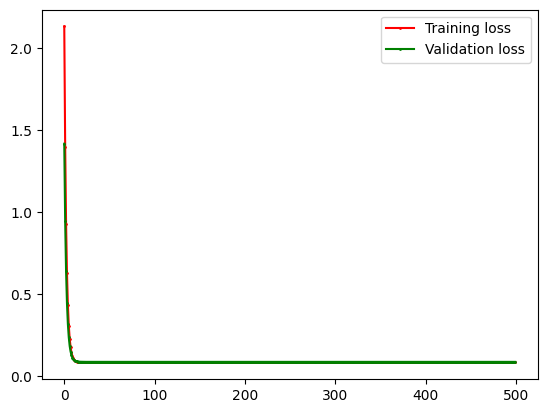

=== Linear Regression Evaluation - Dataset D, lr=0.1 ===
MSE       : 0.0824
MAE       : 0.2467
RMSE      : 0.2870
R-squared : 0.9716


{'MSE': 0.08239246019794483,
 'MAE': 0.24670574882394442,
 'RMSE': np.float64(0.28704086851517296),
 'R-squared': 0.9716056317069087}

In [23]:
# Dataset D, lr=0.1
loaded_data = np.load('data/linear_data/linear_data_D.npz')
X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']
size = X.shape[0]
dim = X.shape[1]-1

seed = 42
np.random.seed(seed)
X_train, y_train, X_val, y_val = get_train_val(X, y)

model = LinearModel(dim, True, MSE, MSE_grad)
model.fit(X_train, y_train, lr=0.1, n_iteration=500, val_ratio=0.2)

y_val_pred = model.predict(X_val)
evaluate_linear_regression(y_true=y_val, y_pred=y_val_pred, title='Linear Regression Evaluation - Dataset D, lr=0.1')

50. Training loss: 0.3703643487722047, Val loss:0.3686849563983318
100. Training loss: 0.1214345969859307, Val loss:0.1255385955779745
150. Training loss: 0.08770086474185745, Val loss:0.09183236776167002
200. Training loss: 0.08311255449810843, Val loss:0.08699540377230673
250. Training loss: 0.0824862834452406, Val loss:0.08624729244656879
300. Training loss: 0.08240051730594523, Val loss:0.08611372904350847
350. Training loss: 0.08238873475630884, Val loss:0.08608430475529508
400. Training loss: 0.0823871112191, Val loss:0.08607630029028919
450. Training loss: 0.0823868868729943, Val loss:0.08607378489771042
500. Training loss: 0.0823868557883243, Val loss:0.08607293368416795


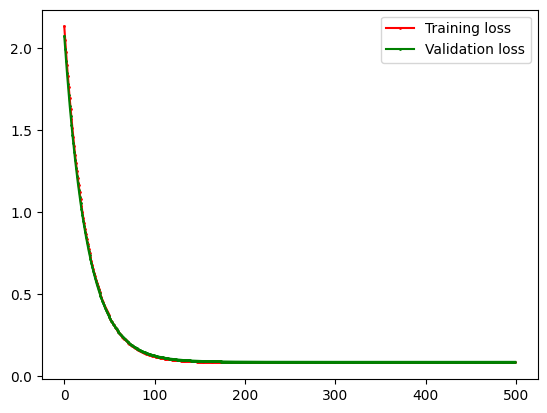

=== Linear Regression Evaluation - Dataset D, lr=0.01 ===
MSE       : 0.0824
MAE       : 0.2467
RMSE      : 0.2870
R-squared : 0.9716


{'MSE': 0.08239259798771861,
 'MAE': 0.24670454246976223,
 'RMSE': np.float64(0.28704110853276504),
 'R-squared': 0.9716055842213308}

In [24]:
# Dataset D, lr=0.01
loaded_data = np.load('data/linear_data/linear_data_D.npz')
X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']
size = X.shape[0]
dim = X.shape[1]-1

seed = 42
np.random.seed(seed)
X_train, y_train, X_val, y_val = get_train_val(X, y)

model = LinearModel(dim, True, MSE, MSE_grad)
model.fit(X_train, y_train, lr=0.01, n_iteration=500, val_ratio=0.2)

y_val_pred = model.predict(X_val)
evaluate_linear_regression(y_true=y_val, y_pred=y_val_pred, title='Linear Regression Evaluation - Dataset D, lr=0.01')

50. Training loss: 1.7684511643778449, Val loss:1.7808955296769526
100. Training loss: 1.4648524964143852, Val loss:1.4770554865390984
150. Training loss: 1.2159645145907354, Val loss:1.2278106296911493
200. Training loss: 1.0119199428934709, Val loss:1.0233353741451867
250. Training loss: 0.8446325767970521, Val loss:0.8555746535033422
300. Training loss: 0.7074755244845349, Val loss:0.7179245466593898
350. Training loss: 0.5950176249327075, Val loss:0.6049705693586136
400. Training loss: 0.50280751484024, Val loss:0.5122732093945561
450. Training loss: 0.4271967232656893, Val loss:0.43619216922708653
500. Training loss: 0.3651947340371162, Val loss:0.3737423235472047


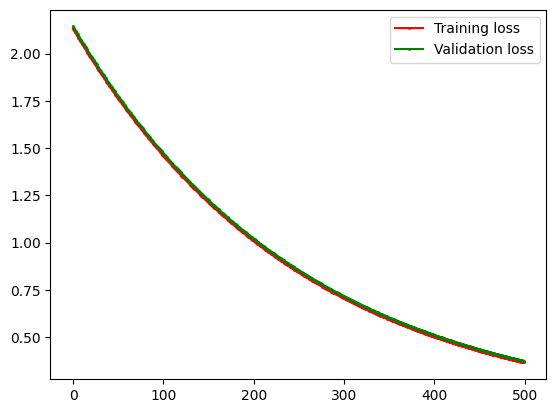

=== Linear Regression Evaluation - Dataset D, lr=0.001 ===
MSE       : 0.3540
MAE       : 0.4778
RMSE      : 0.5950
R-squared : 0.8780


{'MSE': 0.35401418955181013,
 'MAE': 0.4777943162702677,
 'RMSE': np.float64(0.5949909155204054),
 'R-squared': 0.8779984326846808}

In [25]:
# Dataset D, lr=0.001
loaded_data = np.load('data/linear_data/linear_data_D.npz')
X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']
size = X.shape[0]
dim = X.shape[1]-1

seed = 42
np.random.seed(seed)
X_train, y_train, X_val, y_val = get_train_val(X, y)

model = LinearModel(dim, True, MSE, MSE_grad)
model.fit(X_train, y_train, lr=0.001, n_iteration=500, val_ratio=0.2)

y_val_pred = model.predict(X_val)
evaluate_linear_regression(y_true=y_val, y_pred=y_val_pred, title='Linear Regression Evaluation - Dataset D, lr=0.001')

## 1(c): Observations

**Effect of Learning Rate on Linear Regression:**

- **lr = 0.1 (high):** The loss curve descends rapidly in the early iterations and stays low. Contrary to the expectation, this learning rate value is not too high, no divergence occurs.

- **lr = 0.01 (medium):** This learning rate provides a stable and consistent convergence. The training and validation losses decrease smoothly and converge to a good solution within 500 iterations (essentially same one as the high lr).

- **lr = 0.001 (low):** The loss decreases very slowly and does not reach as good of a loss as the higher learning rates. Presumably, training with more iterations would lead to the same loss. This learning rate is way too low.

**Dataset Variability:** The final model performance varied among datasets. Dataset B was catastrophic, reaching very bad results. A was okay and both C and D were fitted wery well by the model. In the training progress curve, there were no big differences between the datasets. Notably, in dataset B, the difference between training and validation loss was the greatest.

**Result:** A low learning rate slows down training and might lead to not finding an optimal solution in the provided amount of iterations. A high learning rate is not troublesome for this task